In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
world_df = pd.read_csv('worldometer_data.csv')
covid_df = pd.read_csv('covid_19_clean_complete.csv')

In [7]:
world_df.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [8]:
covid_df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [9]:
print(world_df.columns.tolist())
print(covid_df.columns.tolist())

['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'WHO Region']
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


In [10]:
##   Checking the size of both datasets

print(world_df.shape)
print(covid_df.shape)

(209, 16)
(49068, 10)


In [11]:
## Checking for missing values in world_df

world_df.isnull().sum()

Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
dtype: int64

In [12]:
## Checking for missing values in covid_df

covid_df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [13]:
##  Droping the columns i do not need from world_df

world_df = world_df.drop(columns=['NewCases', 'NewDeaths', 'NewRecovered', 
                                   'Serious,Critical', 'Tot Cases/1M pop', 
                                   'Deaths/1M pop', 'Tests/1M pop'])
world_df.head()

,Country/Region,Continent,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalTests,WHO Region
0,USA,North America,3.311981e+08,5032179,162804.0,2576668.0,2292707.0,63139605.0,Americas
1,Brazil,South America,2.127107e+08,2917562,98644.0,2047660.0,771258.0,13206188.0,Americas
2,India,Asia,1.381345e+09,2025409,41638.0,1377384.0,606387.0,22149351.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,14606.0,676357.0,180931.0,29716907.0,Europe
4,South Africa,Africa,5.938157e+07,538184,9604.0,387316.0,141264.0,3149807.0,Africa


In [14]:
## Droping columns i do not need from covid_df

covid_df = covid_df.drop(columns=['Lat', 'Long', 'Province/State'])
covid_df.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,2020-01-22,0,0,0,0,Europe
2,Algeria,2020-01-22,0,0,0,0,Africa
3,Andorra,2020-01-22,0,0,0,0,Europe
4,Angola,2020-01-22,0,0,0,0,Africa


In [15]:
##  Converting the Date column to proper date format

covid_df['Date'] = pd.to_datetime(covid_df['Date'])
covid_df.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,2020-01-22,0,0,0,0,Europe
2,Algeria,2020-01-22,0,0,0,0,Africa
3,Andorra,2020-01-22,0,0,0,0,Europe
4,Angola,2020-01-22,0,0,0,0,Africa


In [16]:
## Done with the cleaning
## Now it is time for analysing

In [17]:
## Top 10 countries with most cases

top_cases = world_df.groupby('Country/Region')['TotalCases'].sum().sort_values(ascending=False).head(10)
print(top_cases)

Country/Region
USA             5032179
Brazil          2917562
India           2025409
Russia           871894
South Africa     538184
Mexico           462690
Peru             455409
Chile            366671
Colombia         357710
Spain            354530
Name: TotalCases, dtype: int64


In [18]:
## Top 10 countries with most deaths

top_deaths = world_df.groupby('Country/Region')['TotalDeaths'].sum().sort_values(ascending=False).head(10)
print(top_deaths)

Country/Region
USA       162804.0
Brazil     98644.0
Mexico     50517.0
UK         46413.0
India      41638.0
Italy      35187.0
France     30312.0
Spain      28500.0
Peru       20424.0
Iran       17976.0
Name: TotalDeaths, dtype: float64


In [19]:
##  Which continent was most affected

continent_cases = world_df.groupby('Continent')['TotalCases'].sum().sort_values(ascending=False)
print(continent_cases)

Continent
North America        5919209
Asia                 4689794
South America        4543273
Europe               2982576
Africa               1011867
Australia/Oceania      21735
Name: TotalCases, dtype: int64


In [20]:
## The total worldwide cases deaths and recoveries

print(f"Total Cases: {world_df['TotalCases'].sum():,}")
print(f"Total Deaths: {world_df['TotalDeaths'].sum():,}")
print(f"Total Recovered: {world_df['TotalRecovered'].sum():,}")

Total Cases: 19,169,166
Total Deaths: 713,007.0
Total Recovered: 12,070,191.0


In [21]:
## To know  Hww cases grew over time

time_series = covid_df.groupby('Date')['Confirmed'].sum()
print(time_series)

Date
2020-01-22         555
2020-01-23         654
2020-01-24         941
2020-01-25        1434
2020-01-26        2118
                ...   
2020-07-23    15510481
2020-07-24    15791645
2020-07-25    16047190
2020-07-26    16251796
2020-07-27    16480485
Name: Confirmed, Length: 188, dtype: int64


In [23]:
##  Death rate per country

world_df['Death_Rate'] = (world_df['TotalDeaths'] / world_df['TotalCases']) * 100
death_rate = world_df[['Country/Region', 'Death_Rate']].sort_values('Death_Rate', ascending=False).head(10)
print(death_rate)

     Country/Region  Death_Rate
131           Yemen   28.733032
19           France   15.494318
11               UK   15.062603
15            Italy   14.119757
35          Belgium   13.855083
103         Hungary   13.051990
5            Mexico   10.918109
40      Netherlands   10.798147
179    Sint Maarten   10.000000
208  Western Sahara   10.000000


In [24]:
## Time for Visualization

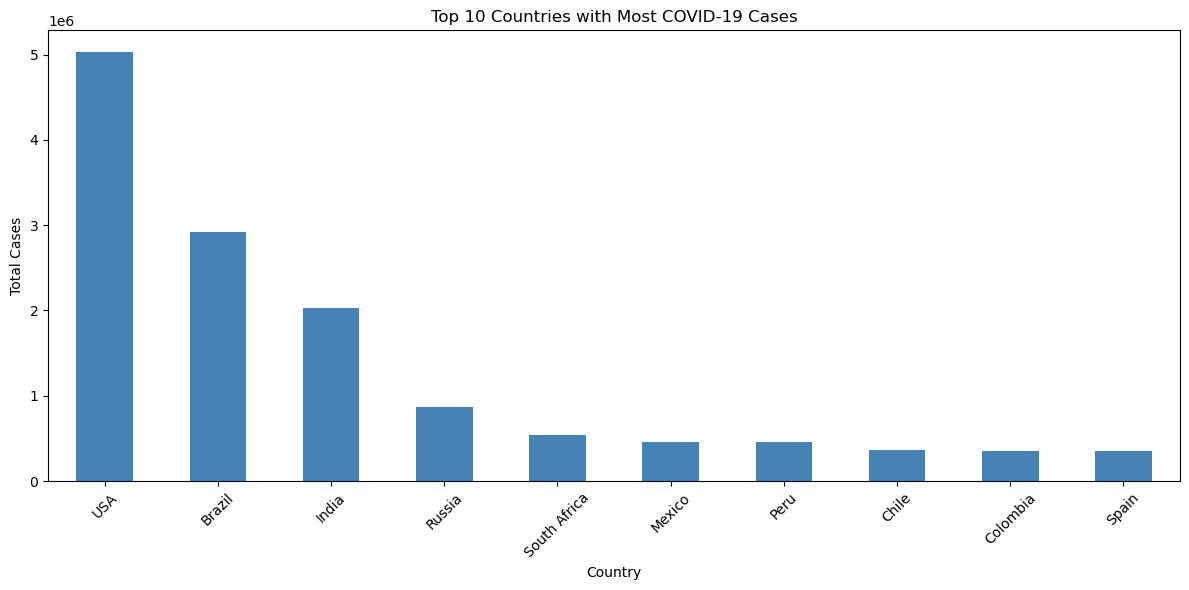

In [25]:
## Top 10 countries with most cases (Bar Chart)

plt.figure(figsize=(12,6))
top_cases.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries with Most COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

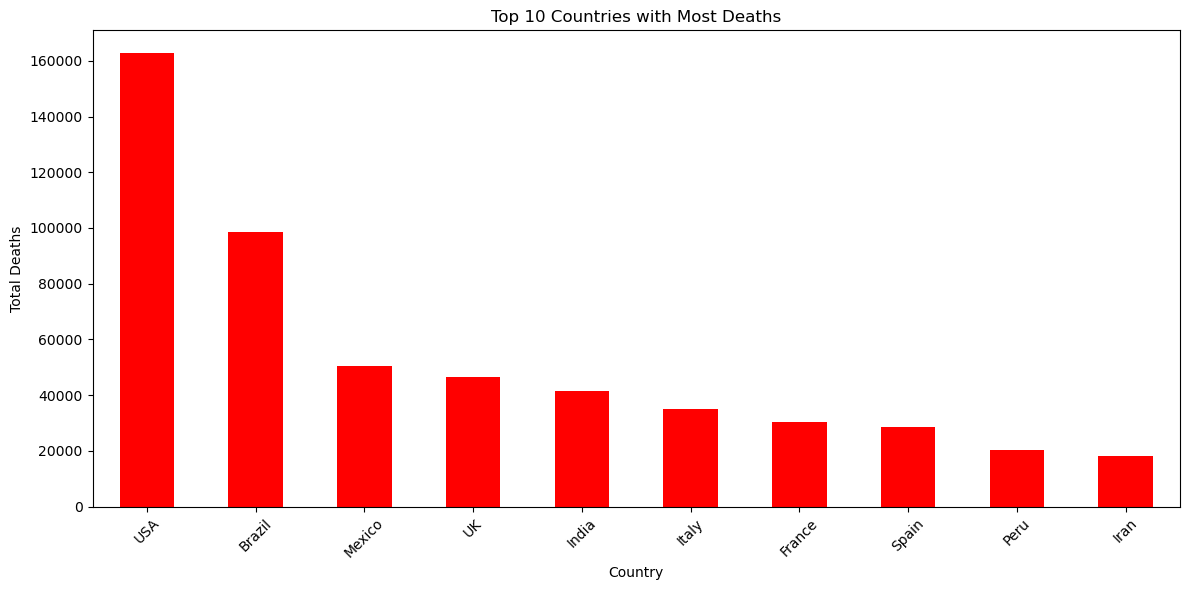

In [26]:
## Top 10 countries with most deaths (Bar Chart)

plt.figure(figsize=(12,6))
top_deaths.plot(kind='bar', color='red')
plt.title('Top 10 Countries with Most Deaths')
plt.xlabel('Country')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

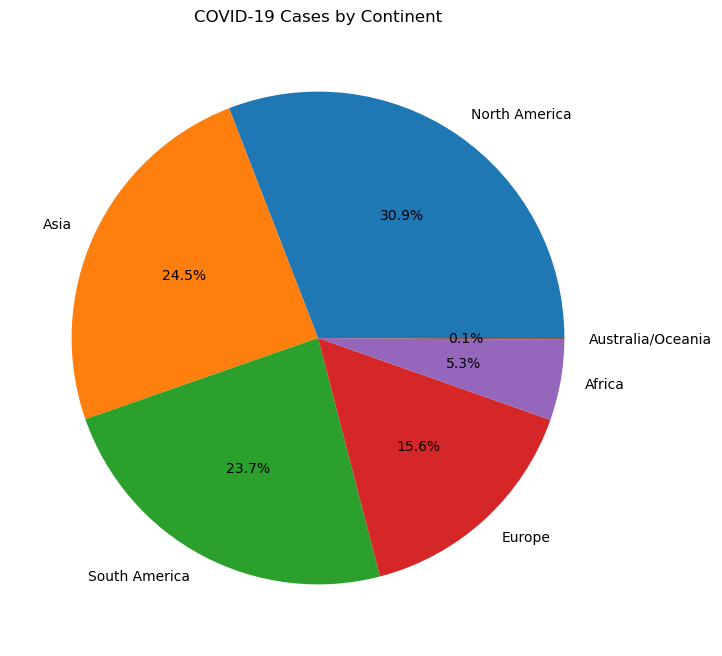

In [27]:
## Cases by Continent (Pie Chart)

plt.figure(figsize=(8,8))
continent_cases.plot(kind='pie', autopct='%1.1f%%')
plt.title('COVID-19 Cases by Continent')
plt.ylabel('')
plt.show()

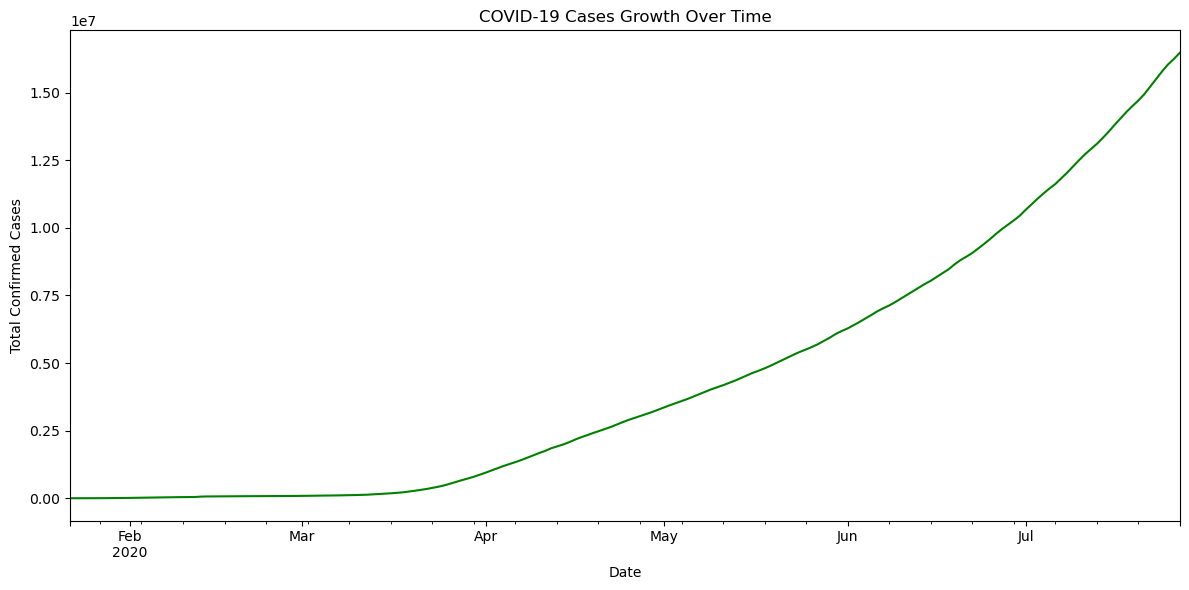

In [28]:
## Cases over time (Line Chart)

plt.figure(figsize=(12,6))
time_series.plot(kind='line', color='green')
plt.title('COVID-19 Cases Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.tight_layout()
plt.show()

In [29]:
world_df.to_csv('world_covid_cleaned.csv', index=False)
covid_df.to_csv('covid_timeseries_cleaned.csv', index=False)

In [30]:
import os
files = os.listdir('C:\\Users\\HP')
print([f for f in files if 'covid' in f.lower()])

['covid_19_clean_complete.csv', 'covid_analysis.ipynb', 'covid_timeseries_cleaned.csv', 'world_covid_cleaned.csv']
